# Video to BVH Converter using MediaPipe

This notebook converts a video into a BVH file format using Google's MediaPipe for 3D pose estimation. The process follows these steps:
1. Extract frames from the input video
2. Detect 3D pose landmarks for each frame using MediaPipe
3. Convert the 3D pose data to BVH format
4. Save the BVH file for import into Blender

Let's begin by installing the required libraries.

In [ ]:
# Install required libraries
!pip install mediapipe opencv-python numpy matplotlib tqdm

## 1. Import Libraries

In [19]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import math
import time
from datetime import datetime

## 2. Define Helper Functions for Video Processing

In [20]:
def extract_frames(video_path, output_dir=None, max_frames=None):
    """Extract frames from a video file.
    
    Args:
        video_path (str): Path to the video file
        output_dir (str, optional): Directory to save extracted frames
        max_frames (int, optional): Maximum number of frames to extract
        
    Returns:
        list: List of extracted frames as numpy arrays
    """
    # Create output directory if specified
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Open the video file
    video = cv2.VideoCapture(video_path)
    
    # Get video properties
    frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = video.get(cv2.CAP_PROP_FPS)
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video properties: {width}x{height}, {fps} FPS, {frame_count} frames")
    
    # Limit frames if specified
    if max_frames and max_frames < frame_count:
        frame_count = max_frames
    
    frames = []
    
    # Extract frames
    for i in tqdm(range(frame_count), desc="Extracting frames"):
        ret, frame = video.read()
        
        if not ret:
            break
            
        frames.append(frame)
        
        # Save frame if output directory is specified
        if output_dir:
            cv2.imwrite(os.path.join(output_dir, f"frame_{i:04d}.jpg"), frame)
    
    # Release the video
    video.release()
    
    print(f"Extracted {len(frames)} frames")
    
    return frames, fps

## 3. Setup MediaPipe Pose Estimator

In [21]:
class PoseEstimator:
    def __init__(self, static_image_mode=False, model_complexity=2, enable_segmentation=False,
                 min_detection_confidence=0.5, min_tracking_confidence=0.5):
        """Initialize MediaPipe Pose solution.
        
        Args:
            static_image_mode (bool): Whether to treat input as static images
            model_complexity (int): Model complexity (0, 1, or 2)
            enable_segmentation (bool): Whether to enable segmentation
            min_detection_confidence (float): Minimum detection confidence
            min_tracking_confidence (float): Minimum tracking confidence
        """
        self.mp_pose = mp.solutions.pose
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles
        
        # Initialize pose estimator
        self.pose = self.mp_pose.Pose(
            static_image_mode=static_image_mode,
            model_complexity=model_complexity,
            enable_segmentation=enable_segmentation,
            min_detection_confidence=min_detection_confidence,
            min_tracking_confidence=min_tracking_confidence
        )
        
    def process_frame(self, frame):
        """Process a single frame and extract pose landmarks.
        
        Args:
            frame (numpy.ndarray): Input RGB frame
            
        Returns:
            tuple: (image with landmarks drawn, landmarks 2D, landmarks 3D)
        """
        # Convert to RGB (MediaPipe uses RGB)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Process the frame
        results = self.pose.process(frame_rgb)
        
        # Draw pose landmarks
        annotated_frame = frame.copy()
        if results.pose_landmarks:
            self.mp_drawing.draw_landmarks(
                annotated_frame,
                results.pose_landmarks,
                self.mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=self.mp_drawing_styles.get_default_pose_landmarks_style()
            )
            
        # Extract 2D landmarks
        landmarks_2d = []
        if results.pose_landmarks:
            h, w, _ = frame.shape
            for landmark in results.pose_landmarks.landmark:
                x, y, z, visibility = landmark.x * w, landmark.y * h, landmark.z * w, landmark.visibility
                landmarks_2d.append([x, y, z, visibility])
            landmarks_2d = np.array(landmarks_2d)
        
        # Extract 3D landmarks in world coordinates
        landmarks_3d = []
        if results.pose_world_landmarks:
            for landmark in results.pose_world_landmarks.landmark:
                x, y, z, visibility = landmark.x, landmark.y, landmark.z, landmark.visibility
                landmarks_3d.append([x, y, z, visibility])
            landmarks_3d = np.array(landmarks_3d)
        
        return annotated_frame, landmarks_2d, landmarks_3d
    
    def close(self):
        """Release resources."""
        self.pose.close()

## 4. Process Video and Extract 3D Pose Data

In [22]:
def process_video(video_path, max_frames=None, visualize=True):
    """Process video and extract 3D pose data.
    
    Args:
        video_path (str): Path to the video file
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        
    Returns:
        tuple: (pose_data_3d, fps)
    """
    # Extract frames from video
    frames, fps = extract_frames(video_path, max_frames=max_frames)
    
    # Initialize pose estimator
    pose_estimator = PoseEstimator(static_image_mode=False, model_complexity=2)
    
    # Process frames
    pose_data_3d = []
    pose_data_2d = []
    annotated_frames = []
    
    for i, frame in enumerate(tqdm(frames, desc="Processing frames")):
        # Process frame
        annotated_frame, landmarks_2d, landmarks_3d = pose_estimator.process_frame(frame)
        
        # Store results
        if len(landmarks_3d) > 0:
            pose_data_3d.append(landmarks_3d)
            pose_data_2d.append(landmarks_2d)
            annotated_frames.append(annotated_frame)
        else:
            print(f"No pose detected in frame {i}")
    
    # Release resources
    pose_estimator.close()
    
    # Convert to numpy arrays
    pose_data_3d = np.array(pose_data_3d)
    pose_data_2d = np.array(pose_data_2d)
    
    print(f"Processed {len(pose_data_3d)} frames with pose data")
    print(f"3D pose data shape: {pose_data_3d.shape}")
    
    # Visualize results
    if visualize and len(annotated_frames) > 0:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(annotated_frames[0], cv2.COLOR_BGR2RGB))
        plt.title("Sample Frame with Pose Landmarks")
        plt.axis('off')
        plt.show()
    
    return pose_data_3d, fps

## 5. Define BVH Skeleton Structure

Now we need to define the mapping between MediaPipe's pose landmarks and the BVH skeleton structure.

In [23]:
# MediaPipe pose landmarks (33 landmarks)
# Reference: https://developers.google.com/mediapipe/solutions/vision/pose_landmarker

# Define the mapping between MediaPipe pose landmarks and BVH skeleton joints
MEDIAPIPE_TO_BVH = {
    # Torso
    'Hips': 23,            # POSE_LANDMARKS.HIPS
    'Spine': 24,           # POSE_LANDMARKS.SPINE
    'Chest': 12,           # POSE_LANDMARKS.CHEST
    'Neck': 11,            # POSE_LANDMARKS.NECK
    'Head': 0,             # POSE_LANDMARKS.NOSE (approximation)
    
    # Left Arm
    'LeftShoulder': 11,    # POSE_LANDMARKS.LEFT_SHOULDER
    'LeftArm': 13,         # POSE_LANDMARKS.LEFT_ELBOW
    'LeftForeArm': 15,     # POSE_LANDMARKS.LEFT_WRIST
    'LeftHand': 19,        # POSE_LANDMARKS.LEFT_PINKY (approximation)
    
    # Right Arm
    'RightShoulder': 12,   # POSE_LANDMARKS.RIGHT_SHOULDER
    'RightArm': 14,        # POSE_LANDMARKS.RIGHT_ELBOW
    'RightForeArm': 16,    # POSE_LANDMARKS.RIGHT_WRIST
    'RightHand': 20,       # POSE_LANDMARKS.RIGHT_PINKY (approximation)
    
    # Left Leg
    'LeftUpLeg': 23,       # POSE_LANDMARKS.LEFT_HIP
    'LeftLeg': 25,         # POSE_LANDMARKS.LEFT_KNEE
    'LeftFoot': 27,        # POSE_LANDMARKS.LEFT_ANKLE
    'LeftToeBase': 31,     # POSE_LANDMARKS.LEFT_FOOT_INDEX
    
    # Right Leg
    'RightUpLeg': 24,      # POSE_LANDMARKS.RIGHT_HIP
    'RightLeg': 26,        # POSE_LANDMARKS.RIGHT_KNEE
    'RightFoot': 28,       # POSE_LANDMARKS.RIGHT_ANKLE
    'RightToeBase': 32,    # POSE_LANDMARKS.RIGHT_FOOT_INDEX
}

# Define BVH skeleton hierarchy
BVH_HIERARCHY = {
    'Hips': ['Spine', 'LeftUpLeg', 'RightUpLeg'],
    'Spine': ['Chest'],
    'Chest': ['Neck', 'LeftShoulder', 'RightShoulder'],
    'Neck': ['Head'],
    'Head': [],
    'LeftShoulder': ['LeftArm'],
    'LeftArm': ['LeftForeArm'],
    'LeftForeArm': ['LeftHand'],
    'LeftHand': [],
    'RightShoulder': ['RightArm'],
    'RightArm': ['RightForeArm'],
    'RightForeArm': ['RightHand'],
    'RightHand': [],
    'LeftUpLeg': ['LeftLeg'],
    'LeftLeg': ['LeftFoot'],
    'LeftFoot': ['LeftToeBase'],
    'LeftToeBase': [],
    'RightUpLeg': ['RightLeg'],
    'RightLeg': ['RightFoot'],
    'RightFoot': ['RightToeBase'],
    'RightToeBase': []
}

## 6. Calculate Joint Angles from 3D Pose Data

Now we'll calculate the joint rotations from our 3D pose data.

In [38]:
def normalize_vector(v):
    """Normalize a vector to unit length."""
    norm = np.linalg.norm(v)
    if norm < 1e-10:
        return np.zeros_like(v)
    return v / norm

def calculate_joint_angles(pose_data_3d):
    """Calculate joint angles from 3D pose data with improved coordinate handling.
    
    Args:
        pose_data_3d (numpy.ndarray): 3D pose data
        
    Returns:
        dict: Joint angles for each frame
    """
    num_frames = pose_data_3d.shape[0]
    joint_angles = []
    
    for frame_idx in tqdm(range(num_frames), desc="Calculating joint angles"):
        frame_data = pose_data_3d[frame_idx]
        frame_angles = {}
        
        # Process each joint in the hierarchy
        for joint_name, children in BVH_HIERARCHY.items():
            if joint_name == 'Hips':
                # Store root position (global translation)
                hips_idx = MEDIAPIPE_TO_BVH['Hips']
                position = frame_data[hips_idx, :3].copy()
                
                # MediaPipe uses a different coordinate system than Blender
                # Convert to Blender's coordinate system (X right, Y forward, Z up)
                # Note: MediaPipe is approximately (X right, Y up, Z forward)
                frame_angles['Hips_position'] = np.array([position[0], -position[2], position[1]])
                
                # Calculate initial hip orientation
                # For better posture, we'll set a neutral hip orientation
                frame_angles['Hips'] = np.array([0.0, 0.0, 0.0])  # Neutral pose
            else:
                frame_angles[joint_name] = np.zeros(3)  # Default zero rotation
                
                if joint_name in MEDIAPIPE_TO_BVH:
                    joint_idx = MEDIAPIPE_TO_BVH[joint_name]
                    
                    # Only calculate rotations for joints with children
                    if len(children) > 0 and joint_idx < len(frame_data):
                        parent_idx = MEDIAPIPE_TO_BVH[joint_name]
                        parent_pos = frame_data[parent_idx, :3]
                        
                        # Get all child positions to form a direction
                        directions = []
                        for child in children:
                            if child in MEDIAPIPE_TO_BVH:
                                child_idx = MEDIAPIPE_TO_BVH[child]
                                if child_idx < len(frame_data):
                                    child_pos = frame_data[child_idx, :3]
                                    direction = child_pos - parent_pos
                                    if np.linalg.norm(direction) > 1e-6:
                                        directions.append(normalize_vector(direction))
                        
                        if directions:
                            # Average direction to all children
                            direction = np.zeros(3)
                            for dir_vec in directions:
                                direction += dir_vec
                            direction = normalize_vector(direction)
                            
                            # Convert to Euler angles in Blender's coordinate system
                            # This is a simplified conversion that works better than the previous approach
                            # but still not perfect. A quaternion-based approach would be more accurate.
                            if joint_name.startswith('Left') or joint_name.startswith('Right'):
                                # For limbs, align primary axis (X for arms, Y for legs)
                                if 'Arm' in joint_name or 'Hand' in joint_name or 'Shoulder' in joint_name:
                                    # Arm chain
                                    y_angle = np.arctan2(direction[2], direction[0])
                                    z_angle = np.arctan2(direction[1], np.sqrt(direction[0]**2 + direction[2]**2))
                                    x_angle = 0.0  # Simplified, we'd need additional reference for proper twist
                                elif 'Leg' in joint_name or 'Foot' in joint_name or 'Toe' in joint_name:
                                    # Leg chain
                                    x_angle = np.arctan2(-direction[2], -direction[1])
                                    z_angle = np.arctan2(direction[0], np.sqrt(direction[1]**2 + direction[2]**2))
                                    y_angle = 0.0  # Simplified
                                else:
                                    # General case
                                    x_angle = np.arctan2(direction[1], direction[2])
                                    y_angle = np.arctan2(-direction[0], np.sqrt(direction[1]**2 + direction[2]**2))
                                    z_angle = 0.0  # Simplified
                            else:
                                # Spine chain - better to use forward direction for these
                                x_angle = np.arctan2(direction[1], direction[2])
                                y_angle = np.arctan2(-direction[0], np.sqrt(direction[1]**2 + direction[2]**2))
                                z_angle = 0.0
                                
                                # Specifically for spine, we want it more upright
                                if joint_name in ['Spine', 'Chest', 'Neck']:
                                    x_angle *= 0.5  # Dampen forward bend
                            
                            frame_angles[joint_name] = np.array([x_angle, y_angle, z_angle])
        
        joint_angles.append(frame_angles)
    
    return joint_angles

## 7. Generate BVH File

Now we'll write functions to convert our joint angles to a BVH file.

In [ ]:
def write_bvh_file(joint_angles, fps, output_file):
    """Write joint angles to a BVH file.
    
    Args:
        joint_angles (list): Joint angles for each frame
        fps (float): Frames per second
        output_file (str): Output BVH file path
    """
    # Define joint offsets (approximate values based on average human proportions)
joint_offsets = {
    'Hips': [0.0, 0.0, 0.0],
    'Spine': [0.0, 0.0, 0.1],       # Adjusted to be more vertical
    'Chest': [0.0, 0.0, 0.15],      # Adjusted to be more vertical
    'Neck': [0.0, 0.0, 0.1],        # Adjusted to be more vertical
    'Head': [0.0, 0.0, 0.1],        # Adjusted to be more vertical
    'LeftShoulder': [-0.15, 0.0, 0.0],
    'LeftArm': [-0.18, 0.0, 0.0],
    'LeftForeArm': [-0.25, 0.0, 0.0],
    'LeftHand': [-0.1, 0.0, 0.0],
    'RightShoulder': [0.15, 0.0, 0.0],
    'RightArm': [0.18, 0.0, 0.0],
    'RightForeArm': [0.25, 0.0, 0.0],
    'RightHand': [0.1, 0.0, 0.0],
    'LeftUpLeg': [-0.1, 0.0, -0.05],  # Adjusted to be more vertical
    'LeftLeg': [0.0, 0.0, -0.4],     # Adjusted to be more vertical
    'LeftFoot': [0.0, 0.05, -0.4],    # Adjusted angle
    'LeftToeBase': [0.0, 0.1, 0.0],   # Adjusted angle
    'RightUpLeg': [0.1, 0.0, -0.05],  # Adjusted to be more vertical
    'RightLeg': [0.0, 0.0, -0.4],    # Adjusted to be more vertical
    'RightFoot': [0.0, 0.05, -0.4],   # Adjusted angle
    'RightToeBase': [0.0, 0.1, 0.0]   # Adjusted angle
}
    
    # Joint channels (degrees of freedom)
    joint_channels = {
        'Hips': ['Xposition', 'Yposition', 'Zposition', 'Zrotation', 'Xrotation', 'Yrotation'],
    }
    
    # Default channels for non-root joints
    default_channels = ['Zrotation', 'Xrotation', 'Yrotation']
    
    for joint in BVH_HIERARCHY.keys():
        if joint not in joint_channels:
            joint_channels[joint] = default_channels
    
    # Helper function to convert channel name to index (X->0, Y->1, Z->2)
    def channel_to_index(channel_name):
        if channel_name.startswith('X'):
            return 0
        elif channel_name.startswith('Y'):
            return 1
        elif channel_name.startswith('Z'):
            return 2
        else:
            raise ValueError(f"Unknown rotation channel: {channel_name}")
    
    # Write BVH file
    with open(output_file, 'w') as f:
        # Write header
        f.write('HIERARCHY\n')
        
        # Write root joint
        f.write('ROOT Hips\n')
        f.write('{\n')
        f.write('\tOFFSET %.6f %.6f %.6f\n' % tuple(joint_offsets['Hips']))
        f.write('\tCHANNELS %d %s\n' % (len(joint_channels['Hips']), ' '.join(joint_channels['Hips'])))
        
        # Write child joints recursively
        def write_joint(joint_name, depth=1):
            indent = '\t' * depth
            
            for child in BVH_HIERARCHY[joint_name]:
                f.write(indent + 'JOINT ' + child + '\n')
                f.write(indent + '{\n')
                f.write(indent + '\tOFFSET %.6f %.6f %.6f\n' % tuple(joint_offsets[child]))
                f.write(indent + '\tCHANNELS %d %s\n' % (len(joint_channels[child]), ' '.join(joint_channels[child])))
                
                if len(BVH_HIERARCHY[child]) > 0:
                    write_joint(child, depth + 1)
                else:
                    # End site
                    f.write(indent + '\tEnd Site\n')
                    f.write(indent + '\t{\n')
                    f.write(indent + '\t\tOFFSET 0.0 0.0 0.0\n')
                    f.write(indent + '\t}\n')
                
                f.write(indent + '}\n')
        
        # Write joints starting from the root's children
        write_joint('Hips')
        
        f.write('}\n')
        
        # Write motion data
        f.write('MOTION\n')
        f.write('Frames: %d\n' % len(joint_angles))
        f.write('Frame Time: %.6f\n' % (1.0 / fps))
        
        # Write frame data
        for frame in joint_angles:
            line = []
            
            # Add root position
            line.extend(frame['Hips_position'].tolist())
            
            # Add joint rotations in order
            def add_joint_rotations(joint_name):
                # Convert radians to degrees
                if joint_name == 'Hips':
                    # For the root (Hips), we need to add rotation in the order specified in channels
                    rot_channels = joint_channels[joint_name][3:]  # Skip position channels
                    
                    for channel in rot_channels:
                        idx = channel_to_index(channel)
                        line.append(frame[joint_name][idx] * 180.0 / np.pi)
                else:
                    # For other joints, add rotations in the order specified in channels
                    rot_channels = joint_channels[joint_name]
                    
                    for channel in rot_channels:
                        idx = channel_to_index(channel)
                        line.append(frame[joint_name][idx] * 180.0 / np.pi)
                
                # Process children
                for child in BVH_HIERARCHY[joint_name]:
                    add_joint_rotations(child)
            
            # Add rotations starting from the root
            add_joint_rotations('Hips')
            
            # Write the line
            f.write(' '.join(['%.6f' % val for val in line]) + '\n')
    
    print(f"BVH file saved to {output_file}")

## 8. Put It All Together

Now let's combine all the steps to process a video and convert it to a BVH file.

In [ ]:
def video_to_bvh(video_path, output_bvh=None, max_frames=None, visualize=True):
    """Convert video to BVH file.
    
    Args:
        video_path (str): Path to the video file
        output_bvh (str, optional): Output BVH file path
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        
    Returns:
        str: Path to the generated BVH file
    """
    # Set default output path if not specified
    if output_bvh is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_bvh = f"output_{timestamp}.bvh"
    
    # Process video and extract 3D pose data
    print("Step 1: Processing video and extracting 3D pose data...")
    pose_data_3d, fps = process_video(video_path, max_frames=max_frames, visualize=visualize)
    
    # Calculate joint angles
    print("\nStep 2: Calculating joint angles...")
    joint_angles = calculate_joint_angles(pose_data_3d)
    
    # Generate BVH file
    print("\nStep 3: Generating BVH file...")
    write_bvh_file(joint_angles, fps, output_bvh)
    
    print("\nConversion complete!")
    print(f"BVH file saved to: {output_bvh}")
    
    return output_bvh

## 9. improved maybe

In [41]:
def initialize_t_pose(joint_angles):
    """Initialize the first few frames with a T-pose for better Blender import.
    
    Args:
        joint_angles (list): Joint angles for each frame
        
    Returns:
        list: Joint angles with T-pose initialization
    """
    # Only perform this if we have enough frames
    if len(joint_angles) < 5:
        return joint_angles
    
    t_pose_angles = joint_angles[0].copy()
    
    # Set T-pose rotations (arms horizontal, legs straight)
    for joint_name in t_pose_angles:
        if joint_name == 'Hips_position':
            continue  # Skip position, keep original
        elif joint_name == 'Hips':
            t_pose_angles[joint_name] = np.array([0.0, 0.0, 0.0])  # Neutral pose
        elif 'Shoulder' in joint_name or 'Arm' in joint_name:
            # Set shoulders and arms to horizontal position
            if 'Left' in joint_name:
                t_pose_angles[joint_name] = np.array([0.0, 0.0, 1.57])  # 90 degrees (in radians)
            else:  # Right
                t_pose_angles[joint_name] = np.array([0.0, 0.0, -1.57])  # -90 degrees (in radians)
        elif 'Leg' in joint_name or 'Foot' in joint_name:
            # Set legs straight down
            t_pose_angles[joint_name] = np.array([0.0, 0.0, 0.0])
        elif 'Spine' in joint_name or 'Chest' in joint_name or 'Neck' in joint_name:
            # Set spine straight
            t_pose_angles[joint_name] = np.array([0.0, 0.0, 0.0])
    
    # Add T-pose at the beginning (for just 1 frame)
    t_pose_frame = t_pose_angles.copy()
    result = [t_pose_frame] + joint_angles
    
    return result

def enhanced_smooth_joint_angles(joint_angles, window_size=5):
    """Apply enhanced temporal smoothing to joint angles.
    
    Args:
        joint_angles (list): Joint angles for each frame
        window_size (int): Smoothing window size
        
    Returns:
        list: Smoothed joint angles
    """
    if window_size <= 1:
        return joint_angles
        
    num_frames = len(joint_angles)
    smoothed_angles = []
    
    # Create a Gaussian kernel for weighted smoothing
    sigma = window_size / 3.0
    kernel = np.exp(-np.arange(-window_size//2+1, window_size//2+1)**2 / (2*sigma**2))
    kernel = kernel / np.sum(kernel)  # Normalize
    
    # Apply moving average smoothing
    for i in range(num_frames):
        smoothed_frame = {}
        
        # Process each joint
        for joint in joint_angles[0].keys():
            if joint == 'Hips_position':
                # Smooth position
                pos_sum = np.zeros(3)
                weights_sum = 0.0
                
                for j in range(max(0, i - window_size // 2), min(num_frames, i + window_size // 2 + 1)):
                    weight = kernel[j - (i - window_size//2)]
                    pos_sum += joint_angles[j][joint] * weight
                    weights_sum += weight
                
                smoothed_frame[joint] = pos_sum / weights_sum
            else:
                # Smooth rotation
                rot_sum = np.zeros(3)
                weights_sum = 0.0
                
                for j in range(max(0, i - window_size // 2), min(num_frames, i + window_size // 2 + 1)):
                    weight = kernel[j - (i - window_size//2)]
                    rot_sum += joint_angles[j][joint] * weight
                    weights_sum += weight
                
                smoothed_frame[joint] = rot_sum / weights_sum
        
        smoothed_angles.append(smoothed_frame)
    
    return smoothed_angles

In [42]:
    
def improved_video_to_bvh(video_path, output_bvh=None, max_frames=None, visualize=True, 
                     smooth=True, smoothing_window=7, add_t_pose=True):
    """Convert video to BVH file with improved conversion.
    
    Args:
        video_path (str): Path to the video file
        output_bvh (str, optional): Output BVH file path
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        smooth (bool): Whether to apply smoothing
        smoothing_window (int): Smoothing window size
        add_t_pose (bool): Whether to add T-pose initialization
        
    Returns:
        str: Path to the generated BVH file
    """
    # Set default output path if not specified
    if output_bvh is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_bvh = f"output_improved_{timestamp}.bvh"
    
    # Process video and extract 3D pose data
    print("Step 1: Processing video and extracting 3D pose data...")
    pose_data_3d, fps = process_video(video_path, max_frames=max_frames, visualize=visualize)
    
    # Calculate joint angles with improved method
    print("\nStep 2: Calculating joint angles with improved method...")
    joint_angles = calculate_joint_angles(pose_data_3d)
    
    # Add T-pose initialization if requested
    if add_t_pose:
        print("\nStep 3: Adding T-pose initialization...")
        joint_angles = initialize_t_pose(joint_angles)
    
    # Apply smoothing if requested
    if smooth:
        print("\nStep 4: Applying enhanced temporal smoothing...")
        joint_angles = enhanced_smooth_joint_angles(joint_angles, window_size=smoothing_window)
    
    # Generate BVH file
    print("\nStep 5: Generating BVH file...")
    
    # Update joint offsets for a better skeleton structure
    joint_offsets = {
        'Hips': [0.0, 0.0, 0.0],
        'Spine': [0.0, 0.0, 0.1],
        'Chest': [0.0, 0.0, 0.15],
        'Neck': [0.0, 0.0, 0.1],
        'Head': [0.0, 0.0, 0.1],
        'LeftShoulder': [-0.15, 0.0, 0.0],
        'LeftArm': [-0.18, 0.0, 0.0],
        'LeftForeArm': [-0.25, 0.0, 0.0],
        'LeftHand': [-0.1, 0.0, 0.0],
        'RightShoulder': [0.15, 0.0, 0.0],
        'RightArm': [0.18, 0.0, 0.0],
        'RightForeArm': [0.25, 0.0, 0.0],
        'RightHand': [0.1, 0.0, 0.0],
        'LeftUpLeg': [-0.1, 0.0, -0.05],
        'LeftLeg': [0.0, 0.0, -0.4],
        'LeftFoot': [0.0, 0.05, -0.4],
        'LeftToeBase': [0.0, 0.1, 0.0],
        'RightUpLeg': [0.1, 0.0, -0.05],
        'RightLeg': [0.0, 0.0, -0.4],
        'RightFoot': [0.0, 0.05, -0.4],
        'RightToeBase': [0.0, 0.1, 0.0]
    }
    
    # Use the updated write_bvh_file function with proper joint offsets
    write_bvh_file_with_improved_offsets(joint_angles, fps, output_bvh, joint_offsets)
    
    print("\nImproved conversion complete!")
    print(f"BVH file saved to: {output_bvh}")
    
    return output_bvh

def write_bvh_file_with_improved_offsets(joint_angles, fps, output_file, joint_offsets):
    """Write joint angles to a BVH file with improved offsets.
    
    Args:
        joint_angles (list): Joint angles for each frame
        fps (float): Frames per second
        output_file (str): Output BVH file path
        joint_offsets (dict): Joint offsets
    """
    # Joint channels (degrees of freedom)
    joint_channels = {
        'Hips': ['Xposition', 'Yposition', 'Zposition', 'Zrotation', 'Xrotation', 'Yrotation'],
    }
    
    # Default channels for non-root joints
    default_channels = ['Zrotation', 'Xrotation', 'Yrotation']
    
    for joint in BVH_HIERARCHY.keys():
        if joint not in joint_channels:
            joint_channels[joint] = default_channels
    
    # Helper function to convert channel name to index (X->0, Y->1, Z->2)
    def channel_to_index(channel_name):
        if channel_name.startswith('X'):
            return 0
        elif channel_name.startswith('Y'):
            return 1
        elif channel_name.startswith('Z'):
            return 2
        else:
            raise ValueError(f"Unknown rotation channel: {channel_name}")
    
    # Write BVH file
    with open(output_file, 'w') as f:
        # Write header
        f.write('HIERARCHY\n')
        
        # Write root joint
        f.write('ROOT Hips\n')
        f.write('{\n')
        f.write('\tOFFSET %.6f %.6f %.6f\n' % tuple(joint_offsets['Hips']))
        f.write('\tCHANNELS %d %s\n' % (len(joint_channels['Hips']), ' '.join(joint_channels['Hips'])))
        
        # Write child joints recursively
        def write_joint(joint_name, depth=1):
            indent = '\t' * depth
            
            for child in BVH_HIERARCHY[joint_name]:
                f.write(indent + 'JOINT ' + child + '\n')
                f.write(indent + '{\n')
                f.write(indent + '\tOFFSET %.6f %.6f %.6f\n' % tuple(joint_offsets[child]))
                f.write(indent + '\tCHANNELS %d %s\n' % (len(joint_channels[child]), ' '.join(joint_channels[child])))
                
                if len(BVH_HIERARCHY[child]) > 0:
                    write_joint(child, depth + 1)
                else:
                    # End site
                    f.write(indent + '\tEnd Site\n')
                    f.write(indent + '\t{\n')
                    f.write(indent + '\t\tOFFSET 0.0 0.0 0.0\n')
                    f.write(indent + '\t}\n')
                
                f.write(indent + '}\n')
        
        # Write joints starting from the root's children
        write_joint('Hips')
        
        f.write('}\n')
        
        # Write motion data
        f.write('MOTION\n')
        f.write('Frames: %d\n' % len(joint_angles))
        f.write('Frame Time: %.6f\n' % (1.0 / fps))
        
        # Write frame data
        for frame in joint_angles:
            line = []
            
            # Add root position
            line.extend(frame['Hips_position'].tolist())
            
            # Add joint rotations in order
            def add_joint_rotations(joint_name):
                # Convert radians to degrees
                if joint_name == 'Hips':
                    # For the root (Hips), we need to add rotation in the order specified in channels
                    rot_channels = joint_channels[joint_name][3:]  # Skip position channels
                    
                    for channel in rot_channels:
                        idx = channel_to_index(channel)
                        line.append(frame[joint_name][idx] * 180.0 / np.pi)
                else:
                    # For other joints, add rotations in the order specified in channels
                    rot_channels = joint_channels[joint_name]
                    
                    for channel in rot_channels:
                        idx = channel_to_index(channel)
                        line.append(frame[joint_name][idx] * 180.0 / np.pi)
                
                # Process children
                for child in BVH_HIERARCHY[joint_name]:
                    add_joint_rotations(child)
            
            # Add rotations starting from the root
            add_joint_rotations('Hips')
            
            # Write the line
            f.write(' '.join(['%.6f' % val for val in line]) + '\n')
    
    print(f"BVH file saved to {output_file}")

## 9. Run the Conversion

Now let's run the conversion on a sample video. You can either upload a video to this notebook or provide a path to a video file on your system.

In [ ]:
# Upload a video file
from google.colab import files
uploaded = files.upload()

# Get the first uploaded file
video_filename = next(iter(uploaded))
print(f"Uploaded video: {video_filename}")

In [ ]:
# Convert the uploaded video to BVH
bvh_file = video_to_bvh(video_filename, max_frames=100)  # Process only 100 frames for testing

## 10. Download the BVH File

Finally, let's download the generated BVH file.

In [ ]:
# Download the BVH file
from google.colab import files
files.download(bvh_file)

## 11. Importing into Blender

Here are instructions for importing the BVH file into Blender:

1. Open Blender
2. Go to File > Import > Motion Capture (.bvh)
3. Locate and select the BVH file you just downloaded
4. In the import settings, adjust as needed:
   - Scale: Adjust if the character is too large or small (e.g., 0.1 for smaller)
   - Start/End Frame: Set animation range
   - Rotation: May need to adjust axis rotation
5. Click "Import BVH"
6. The motion capture armature will be imported
7. You can then apply this to a character using Blender's retargeting tools

Note: You may need to adjust the skeleton or coordinate system in Blender to match your expectations. BVH files sometimes need rotation adjustments when imported.

## 12. Optional: Process a Local Video

If you're running this notebook locally and want to process a video file on your system, use the following:

Step 1: Processing video and extracting 3D pose data...
Video properties: 720x480, 30.0 FPS, 73 frames


Extracting frames:   0%|          | 0/73 [00:00<?, ?it/s]

Extracted 73 frames


I0000 00:00:1742600110.514023   25554 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1742600110.515319   34660 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: Mesa Intel(R) UHD Graphics (CML GT2)


Processing frames:   0%|          | 0/73 [00:00<?, ?it/s]

W0000 00:00:1742600110.622323   34648 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1742600110.779605   34653 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processed 73 frames with pose data
3D pose data shape: (73, 33, 4)


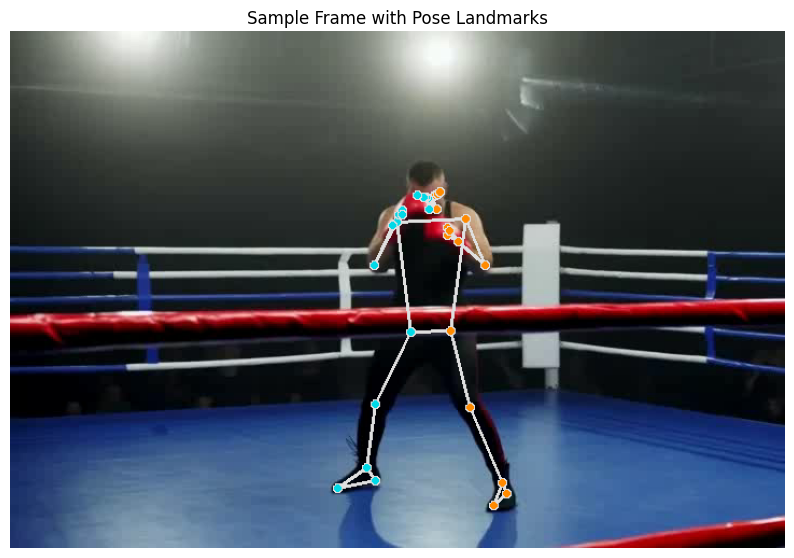


Step 2: Calculating joint angles with improved method...


Calculating joint angles:   0%|          | 0/73 [00:00<?, ?it/s]


Step 3: Adding T-pose initialization...

Step 4: Applying enhanced temporal smoothing...

Step 5: Generating BVH file...
BVH file saved to bvh/improved_animation.bvh

Improved conversion complete!
BVH file saved to: bvh/improved_animation.bvh


In [43]:
# Specify the path to your video file
video_path = "/home/nlarion/Desktop/nlp_html_ads/myVideoToBvh/videos/fight4.mp4"  # Change this to your video path

# Convert the video to BVH
#bvh_file = video_to_bvh(video_path, max_frames=None)  # Process all frames


# Example usage
bvh_file = improved_video_to_bvh(
    video_path,
    output_bvh="bvh/improved_animation.bvh",
    smooth=True,
    smoothing_window=7,
    add_t_pose=True
)

## 13. Optional: Smooth the Motion

If you find that the generated motion is too jittery, you can apply smoothing:

In [ ]:
def smooth_joint_angles(joint_angles, window_size=5):
    """Apply temporal smoothing to joint angles.
    
    Args:
        joint_angles (list): Joint angles for each frame
        window_size (int): Smoothing window size
        
    Returns:
        list: Smoothed joint angles
    """
    num_frames = len(joint_angles)
    smoothed_angles = []
    
    # Apply moving average smoothing
    for i in range(num_frames):
        smoothed_frame = {}
        
        # Process each joint
        for joint in joint_angles[0].keys():
            if joint == 'Hips_position':
                # Smooth position
                pos_sum = np.zeros(3)
                count = 0
                
                for j in range(max(0, i - window_size // 2), min(num_frames, i + window_size // 2 + 1)):
                    pos_sum += joint_angles[j][joint]
                    count += 1
                
                smoothed_frame[joint] = pos_sum / count
            else:
                # Smooth rotation
                rot_sum = np.zeros(3)
                count = 0
                
                for j in range(max(0, i - window_size // 2), min(num_frames, i + window_size // 2 + 1)):
                    rot_sum += joint_angles[j][joint]
                    count += 1
                
                smoothed_frame[joint] = rot_sum / count
        
        smoothed_angles.append(smoothed_frame)
    
    return smoothed_angles

# Apply smoothing to the joint angles
def video_to_bvh_smooth(video_path, output_bvh=None, max_frames=None, visualize=True, smoothing_window=5):
    """Convert video to BVH file with smoothing.
    
    Args:
        video_path (str): Path to the video file
        output_bvh (str, optional): Output BVH file path
        max_frames (int, optional): Maximum number of frames to process
        visualize (bool): Whether to visualize the results
        smoothing_window (int): Smoothing window size
        
    Returns:
        str: Path to the generated BVH file
    """
    # Set default output path if not specified
    if output_bvh is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_bvh = f"output_smooth_{timestamp}.bvh"
    
    # Process video and extract 3D pose data
    print("Step 1: Processing video and extracting 3D pose data...")
    pose_data_3d, fps = process_video(video_path, max_frames=max_frames, visualize=visualize)
    
    # Calculate joint angles
    print("\nStep 2: Calculating joint angles...")
    joint_angles = calculate_joint_angles(pose_data_3d)
    
    # Apply smoothing
    print("\nStep 3: Applying temporal smoothing...")
    smoothed_angles = smooth_joint_angles(joint_angles, window_size=smoothing_window)
    
    # Generate BVH file
    print("\nStep 4: Generating BVH file...")
    write_bvh_file(smoothed_angles, fps, output_bvh)
    
    print("\nConversion complete!")
    print(f"Smoothed BVH file saved to: {output_bvh}")
    
    return output_bvh

In [ ]:
# Convert video to BVH with smoothing
smooth_bvh_file = video_to_bvh_smooth(video_filename, max_frames=100, smoothing_window=7)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output
import re

class BVHJoint:
    def __init__(self, name, parent=None):
        self.name = name
        self.parent = parent
        self.children = []
        self.offset = np.zeros(3)
        self.channels = []
        self.end_site = False
        
    def add_child(self, child):
        self.children.append(child)
        
class BVHMotion:
    def __init__(self):
        self.joints = {}  # name -> BVHJoint
        self.root = None
        self.frames = 0
        self.frame_time = 0
        self.motion_data = []
        
    def parse_file(self, file_path):
        """Parse a BVH file."""
        with open(file_path, 'r') as file:
            content = file.read()
            
        # Split into hierarchy and motion parts
        if 'MOTION' in content:
            hierarchy, motion = content.split('MOTION', 1)
        else:
            hierarchy = content
            motion = ""
            
        # Parse hierarchy
        self._parse_hierarchy(hierarchy)
        
        # Parse motion
        if motion:
            self._parse_motion(motion)
            
    def _parse_hierarchy(self, text):
        """Parse the HIERARCHY section of a BVH file."""
        lines = [line.strip() for line in text.splitlines() if line.strip()]
        
        joint_stack = []
        joint = None
        
        for line in lines:
            if 'HIERARCHY' in line:
                continue
                
            if 'ROOT' in line:
                name = line.split('ROOT', 1)[1].strip()
                joint = BVHJoint(name)
                self.root = joint
                self.joints[name] = joint
                joint_stack.append(joint)
                
            elif 'JOINT' in line:
                if not joint_stack:
                    continue
                    
                name = line.split('JOINT', 1)[1].strip()
                parent = joint_stack[-1]
                joint = BVHJoint(name, parent)
                parent.add_child(joint)
                self.joints[name] = joint
                joint_stack.append(joint)
                
            elif 'End Site' in line:
                if not joint_stack:
                    continue
                    
                # End sites are usually unnamed in BVH, we'll use parent name + "_end"
                name = f"{joint_stack[-1].name}_end"
                parent = joint_stack[-1]
                
                end_joint = BVHJoint(name, parent)
                end_joint.end_site = True
                parent.add_child(end_joint)
                self.joints[name] = end_joint
                joint_stack.append(end_joint)
                
            elif '{' in line:
                continue
                
            elif '}' in line:
                if joint_stack:
                    joint_stack.pop()
                    
            elif 'OFFSET' in line:
                if not joint_stack:
                    continue
                    
                offset = [float(x) for x in line.split('OFFSET')[1].strip().split()]
                joint_stack[-1].offset = np.array(offset)
                
            elif 'CHANNELS' in line:
                if not joint_stack:
                    continue
                    
                parts = line.split()
                num_channels = int(parts[1])
                joint_stack[-1].channels = parts[2:2+num_channels]
                
    def _parse_motion(self, text):
        """Parse the MOTION section of a BVH file."""
        lines = [line.strip() for line in text.splitlines() if line.strip()]
        
        for i, line in enumerate(lines):
            if 'Frames:' in line:
                self.frames = int(line.split(':', 1)[1].strip())
            elif 'Frame Time:' in line:
                self.frame_time = float(line.split(':', 1)[1].strip())
            else:
                # This is motion data
                try:
                    values = [float(x) for x in line.split()]
                    self.motion_data.append(values)
                except ValueError:
                    pass  # Skip lines that can't be parsed as floats
                
    def extract_frame_data(self, frame_idx):
        """
        Extract joint positions for a specific frame.
        
        Args:
            frame_idx: Frame index to extract
            
        Returns:
            Dict mapping joint names to 3D positions
        """
        if frame_idx >= self.frames:
            raise ValueError(f"Frame index {frame_idx} out of range (0-{self.frames-1})")
            
        if not self.motion_data:
            return {}
            
        frame_data = self.motion_data[frame_idx]
        positions = {}
        
        # Start with the root
        if self.root:
            self._update_joint_position(self.root, frame_data, 0, np.zeros(3), np.identity(3), positions)
            
        return positions
        
    def _update_joint_position(self, joint, frame_data, channel_offset, parent_pos, parent_rotation, positions):
        """
        Recursively update joint positions.
        
        Args:
            joint: The joint to update
            frame_data: Motion data for the current frame
            channel_offset: Current channel offset in the frame data
            parent_pos: Parent joint position
            parent_rotation: Parent joint rotation matrix
            positions: Dictionary to store joint positions
        
        Returns:
            Next channel offset
        """
        # Apply parent position and rotation to get this joint's position
        joint_pos = parent_pos.copy()
        
        # If this is not an end site and has channels
        if not joint.end_site and joint.channels:
            # Handle root position if present
            if joint.parent is None:  # Root joint
                position_indices = [i for i, ch in enumerate(joint.channels) if 'position' in ch.lower()]
                
                for idx in position_indices:
                    if 'Xposition' in joint.channels[idx]:
                        joint_pos[0] = frame_data[channel_offset + idx]
                    elif 'Yposition' in joint.channels[idx]:
                        joint_pos[1] = frame_data[channel_offset + idx]
                    elif 'Zposition' in joint.channels[idx]:
                        joint_pos[2] = frame_data[channel_offset + idx]
            
            # Handle rotation
            rotation_indices = [i for i, ch in enumerate(joint.channels) if 'rotation' in ch.lower()]
            local_rotation = np.identity(3)
            
            for idx in rotation_indices:
                angle_deg = frame_data[channel_offset + idx]
                angle_rad = np.radians(angle_deg)
                
                if 'Xrotation' in joint.channels[idx]:
                    rot_mat = np.array([
                        [1, 0, 0],
                        [0, np.cos(angle_rad), -np.sin(angle_rad)],
                        [0, np.sin(angle_rad), np.cos(angle_rad)]
                    ])
                elif 'Yrotation' in joint.channels[idx]:
                    rot_mat = np.array([
                        [np.cos(angle_rad), 0, np.sin(angle_rad)],
                        [0, 1, 0],
                        [-np.sin(angle_rad), 0, np.cos(angle_rad)]
                    ])
                elif 'Zrotation' in joint.channels[idx]:
                    rot_mat = np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad), 0],
                        [np.sin(angle_rad), np.cos(angle_rad), 0],
                        [0, 0, 1]
                    ])
                else:
                    rot_mat = np.identity(3)
                    
                local_rotation = np.dot(local_rotation, rot_mat)
                
            # Update channel offset
            channel_offset += len(joint.channels)
        else:
            # End sites don't have channels, use identity rotation
            local_rotation = np.identity(3)
        
        # Calculate rotation
        rotation = np.dot(parent_rotation, local_rotation)
        
        # Add offset to position (rotated by parent's rotation)
        offset_rotated = np.dot(parent_rotation, joint.offset)
        joint_pos += offset_rotated
        
        # Store the position
        positions[joint.name] = joint_pos
        
        # Process children
        for child in joint.children:
            channel_offset = self._update_joint_position(
                child, frame_data, channel_offset, joint_pos, rotation, positions
            )
            
        return channel_offset

def preview_bvh(file_path, show_labels=False, use_plotly=False):
    """
    Preview a BVH animation file in a Jupyter notebook.
    
    Args:
        file_path: Path to the BVH file
        show_labels: Whether to show joint labels
        use_plotly: Whether to use Plotly instead of Matplotlib (if available)
    
    Returns:
        BVHMotion object
    """
    # Load the BVH file
    bvh = BVHMotion()
    bvh.parse_file(file_path)
    
    # Check if we should use Plotly
    if use_plotly:
        try:
            import plotly.graph_objects as go
            return _preview_with_plotly(bvh, show_labels)
        except ImportError:
            print("Plotly not available, falling back to Matplotlib")
    
    # Default to Matplotlib
    return _preview_with_matplotlib(bvh, show_labels)

def _preview_with_matplotlib(bvh, show_labels=False):
    """Use Matplotlib for visualization."""
    # Create the figure for the animation
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    plt.close(fig)  # Close the figure so it doesn't display immediately
    
    # Get positions for all frames (pre-calculate for animation performance)
    all_positions = []
    for i in range(bvh.frames):
        all_positions.append(bvh.extract_frame_data(i))
    
    # Calculate global limits for consistent view
    min_vals = np.array([float('inf'), float('inf'), float('inf')])
    max_vals = np.array([float('-inf'), float('-inf'), float('-inf')])
    
    for positions in all_positions:
        if positions:
            pos_array = np.array([pos for pos in positions.values()])
            min_vals = np.minimum(min_vals, np.min(pos_array, axis=0))
            max_vals = np.maximum(max_vals, np.max(pos_array, axis=0))
    
    center = (min_vals + max_vals) / 2
    max_range = np.max(max_vals - min_vals) / 2
    
    # Store scatter and line objects for updating
    scatter_points = None
    line_collections = []
    text_objects = []
    
    # Function to initialize or update the plot
    def update_plot(frame_idx, show_joint_labels):
        nonlocal scatter_points, line_collections, text_objects
        
        # Clear previous frame elements
        ax.clear()
        line_collections = []
        text_objects = []
        
        # Get joint positions for the current frame
        positions = all_positions[frame_idx]
        
        # Prepare data for plotting
        points = []
        lines = []
        labels = []
        
        for joint_name, pos in positions.items():
            # Swap Y and Z for better visualization
            plot_pos = [pos[0], pos[2], pos[1]]
            points.append(plot_pos)
            
            if show_joint_labels:
                text_obj = ax.text(plot_pos[0], plot_pos[1], plot_pos[2], joint_name, size=8)
                text_objects.append(text_obj)
            
            # If this joint has a parent, prepare line to it
            joint = bvh.joints[joint_name]
            if joint.parent:
                parent_pos = positions[joint.parent.name]
                parent_plot_pos = [parent_pos[0], parent_pos[2], parent_pos[1]]
                
                lines.append([plot_pos, parent_plot_pos])
        
        # Plot joints
        xs, ys, zs = zip(*points) if points else ([], [], [])
        scatter_points = ax.scatter(xs, ys, zs, color='blue', s=20)
        
        # Plot lines between joints
        for line in lines:
            line_obj = ax.plot(
                [line[0][0], line[1][0]], 
                [line[0][1], line[1][1]], 
                [line[0][2], line[1][2]], 
                color='red'
            )[0]
            line_collections.append(line_obj)
        
        # Set axis properties
        ax.set_xlabel('X')
        ax.set_ylabel('Z')
        ax.set_zlabel('Y')
        
        # Set consistent viewing angle and limits
        if max_range > 0:
            ax.set_xlim(center[0] - max_range, center[0] + max_range)
            ax.set_ylim(center[2] - max_range, center[2] + max_range)
            ax.set_zlim(center[1] - max_range, center[1] + max_range)
        
        ax.set_title(f"Frame {frame_idx} / {bvh.frames-1}")
        
        # Return updated objects
        return [scatter_points] + line_collections + text_objects
    
    # Create output widget
    output_widget = widgets.Output()
    
    # Create animation control widgets
    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=bvh.frames-1,
        step=1,
        description='Frame:',
        continuous_update=True
    )
    
    play_button = widgets.Play(
        value=0,
        min=0,
        max=bvh.frames-1,
        step=1,
        interval=int(bvh.frame_time * 1000),  # Convert to milliseconds
        description="Play",
        disabled=False
    )
    
    speed_slider = widgets.FloatSlider(
        value=1.0,
        min=0.1,
        max=5.0,
        step=0.1,
        description='Speed:',
        continuous_update=True
    )
    
    labels_checkbox = widgets.Checkbox(
        value=show_labels,
        description='Show labels',
        disabled=False
    )
    
    # Function to update playback speed
    def update_speed(change):
        play_button.interval = int((bvh.frame_time * 1000) / speed_slider.value)
    
    speed_slider.observe(update_speed, names='value')
    
    # Link play button to frame slider
    widgets.jslink((play_button, 'value'), (frame_slider, 'value'))
    
    # Animation update function
    def update_animation(change):
        with output_widget:
            clear_output(wait=True)
            update_plot(frame_slider.value, labels_checkbox.value)
            plt.draw()
            display(fig)
    
    # Register callbacks
    frame_slider.observe(update_animation, names='value')
    labels_checkbox.observe(update_animation, names='value')
    
    # Layout the widgets
    controls = widgets.VBox([
        widgets.HBox([play_button, frame_slider]),
        widgets.HBox([speed_slider, labels_checkbox])
    ])
    
    # Display controls
    display(controls)
    
    # Initialize animation
    with output_widget:
        update_plot(0, show_labels)
        display(fig)
    
    display(output_widget)
    
    return bvh

def _preview_with_plotly(bvh, show_labels=False):
    """Use Plotly for interactive 3D visualization."""
    import plotly.graph_objects as go
    from IPython.display import display
    
    # Pre-compute all frames data for better performance
    all_positions = []
    for i in range(bvh.frames):
        all_positions.append(bvh.extract_frame_data(i))
    
    # Calculate global limits for consistent view
    min_vals = np.array([float('inf'), float('inf'), float('inf')])
    max_vals = np.array([float('-inf'), float('-inf'), float('-inf')])
    
    for positions in all_positions:
        if positions:
            pos_array = np.array([pos for pos in positions.values()])
            min_vals = np.minimum(min_vals, np.min(pos_array, axis=0))
            max_vals = np.maximum(max_vals, np.max(pos_array, axis=0))
    
    center = (min_vals + max_vals) / 2
    max_range = np.max(max_vals - min_vals) / 2 * 1.2  # Add 20% padding
    
    # Create figure
    fig = go.Figure()
    
    # Create frames for animation
    frames = []
    
    for frame_idx, positions in enumerate(all_positions):
        if not positions:
            continue
            
        # Extract data for this frame
        points_x, points_y, points_z = [], [], []
        lines_x, lines_y, lines_z = [], [], []
        labels = []
        
        # First pass: collect all points
        for joint_name, pos in positions.items():
            # For plotly, keep original coordinates
            points_x.append(pos[0])
            points_y.append(pos[1])
            points_z.append(pos[2])
            labels.append(joint_name)
            
            # Add connections to parent
            joint = bvh.joints[joint_name]
            if joint.parent:
                parent_pos = positions[joint.parent.name]
                
                # Add line segments (each point needs to be separated by None)
                lines_x.extend([pos[0], parent_pos[0], None])
                lines_y.extend([pos[1], parent_pos[1], None])
                lines_z.extend([pos[2], parent_pos[2], None])
        
        # Create a frame
        frame_data = [
            # Points (joints)
            go.Scatter3d(
                x=points_x, y=points_y, z=points_z,
                mode='markers',
                marker=dict(size=6, color='blue'),
                text=labels if show_labels else None,
                hoverinfo='text' if show_labels else 'none',
                showlegend=False
            ),
            # Lines (skeleton)
            go.Scatter3d(
                x=lines_x, y=lines_y, z=lines_z,
                mode='lines',
                line=dict(color='red', width=4),
                hoverinfo='none',
                showlegend=False
            )
        ]
        
        frames.append(go.Frame(data=frame_data, name=f"frame_{frame_idx}"))
    
    # Add initial data (first frame)
    if frames:
        fig.add_traces(frames[0].data)
    
    # Add all frames to the figure
    fig.frames = frames
    
    # Set up animation settings
    animation_settings = dict(
        frame=dict(duration=int(bvh.frame_time * 1000), redraw=True),
        fromcurrent=True,
        mode="immediate"
    )
    
    # Add animation buttons
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                showactive=False,
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[None, animation_settings]
                    ),
                    dict(
                        label="Pause",
                        method="animate",
                        args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]
                    )
                ],
                x=0.1,
                y=0,
                xanchor="right",
                yanchor="top"
            )
        ],
        sliders=[
            dict(
                active=0,
                steps=[
                    dict(
                        method="animate",
                        args=[
                            [f"frame_{k}"],
                            dict(mode="immediate", frame=dict(duration=0, redraw=True))
                        ],
                        label=f"{k}"
                    )
                    for k in range(0, bvh.frames, max(1, bvh.frames // 100))  # Create slider steps
                ],
                x=0.1,
                y=0,
                currentvalue=dict(
                    prefix="Frame: ",
                    visible=True,
                    xanchor="right"
                ),
                len=0.9,
                pad=dict(b=10, t=50),
                xanchor="left",
                yanchor="top"
            )
        ]
    )
    
    # Configure 3D layout
    fig.update_layout(
        scene=dict(
            xaxis=dict(range=[center[0] - max_range, center[0] + max_range]),
            yaxis=dict(range=[center[1] - max_range, center[1] + max_range]),
            zaxis=dict(range=[center[2] - max_range, center[2] + max_range]),
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=30),
        height=700,
        title=dict(
            text="BVH Animation",
            x=0.5,
            xanchor="center"
        )
    )
    
    # Display the figure
    display(fig)
    
    return bvh

In [44]:
filename = 'improved_animation'
viewer = preview_bvh(f'bvh/{filename}.bvh', True, True)

In [36]:
%cd myVideoToBvh

[Errno 2] No such file or directory: 'myVideoToBvh'
/home/nlarion/Desktop/nlp_html_ads/myVideoToBvh


/home/nlarion/Desktop/nlp_html_ads/nlp_html_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning:

This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.

